# Combining classifiers via majority vote
# Implementing a simple majority vote classifire
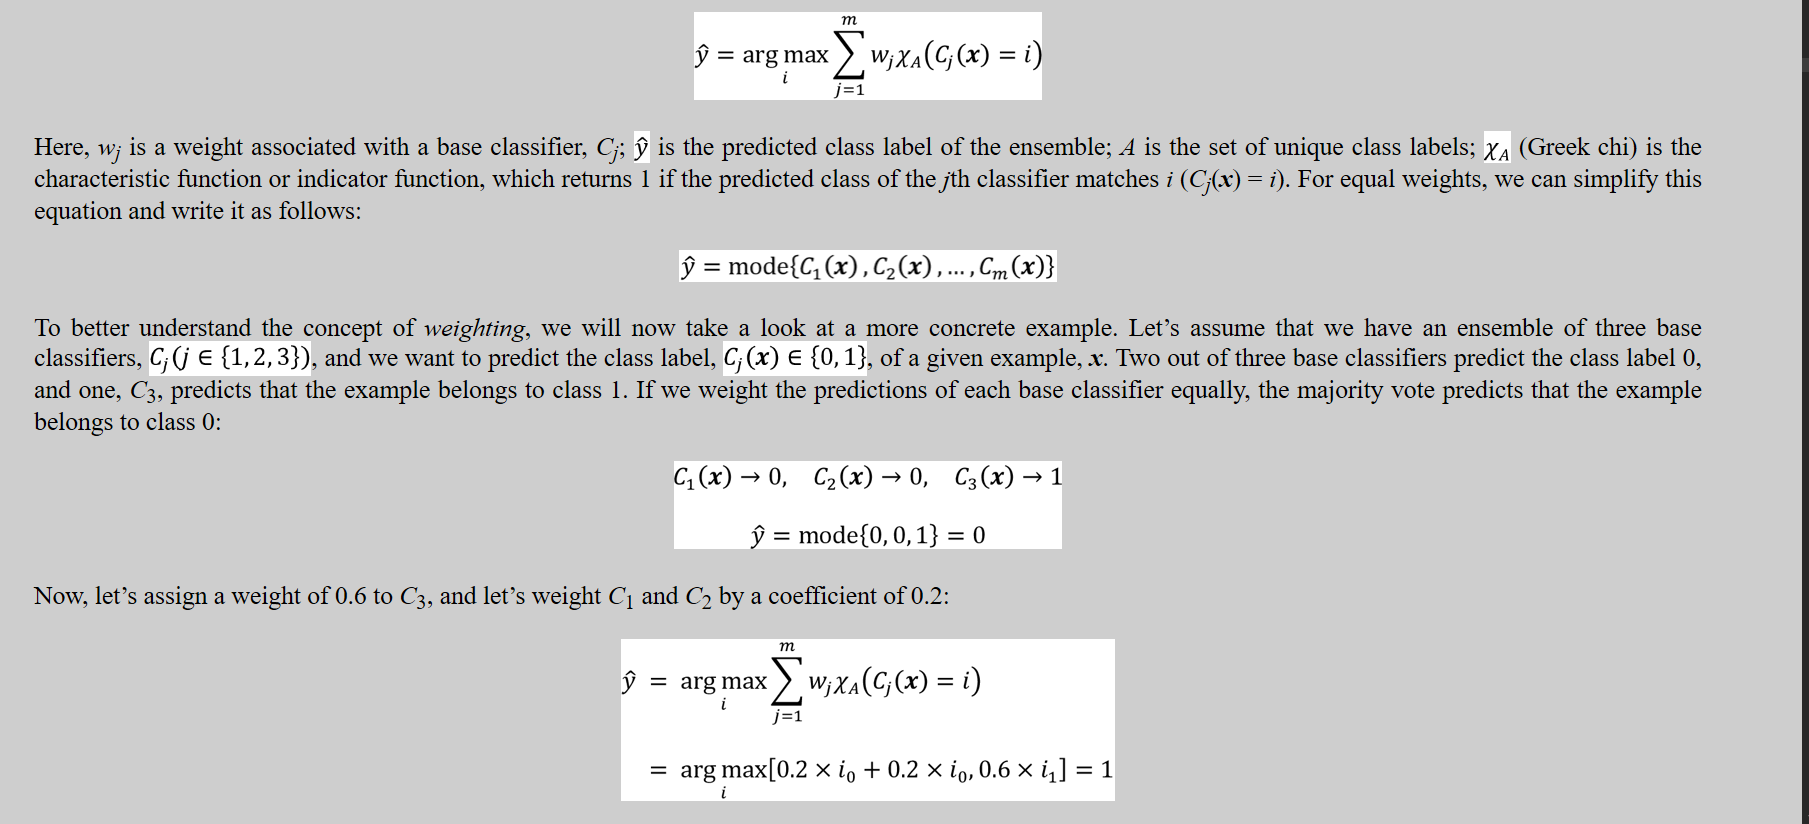

In [1]:
# We can use numpy argmax to do this

import numpy as np

np.argmax(np.bincount([0,0,1], weights = [0.2,0.2,0.6]))



np.int64(1)

# We can also use class probabilty like in pipeline workflow repo
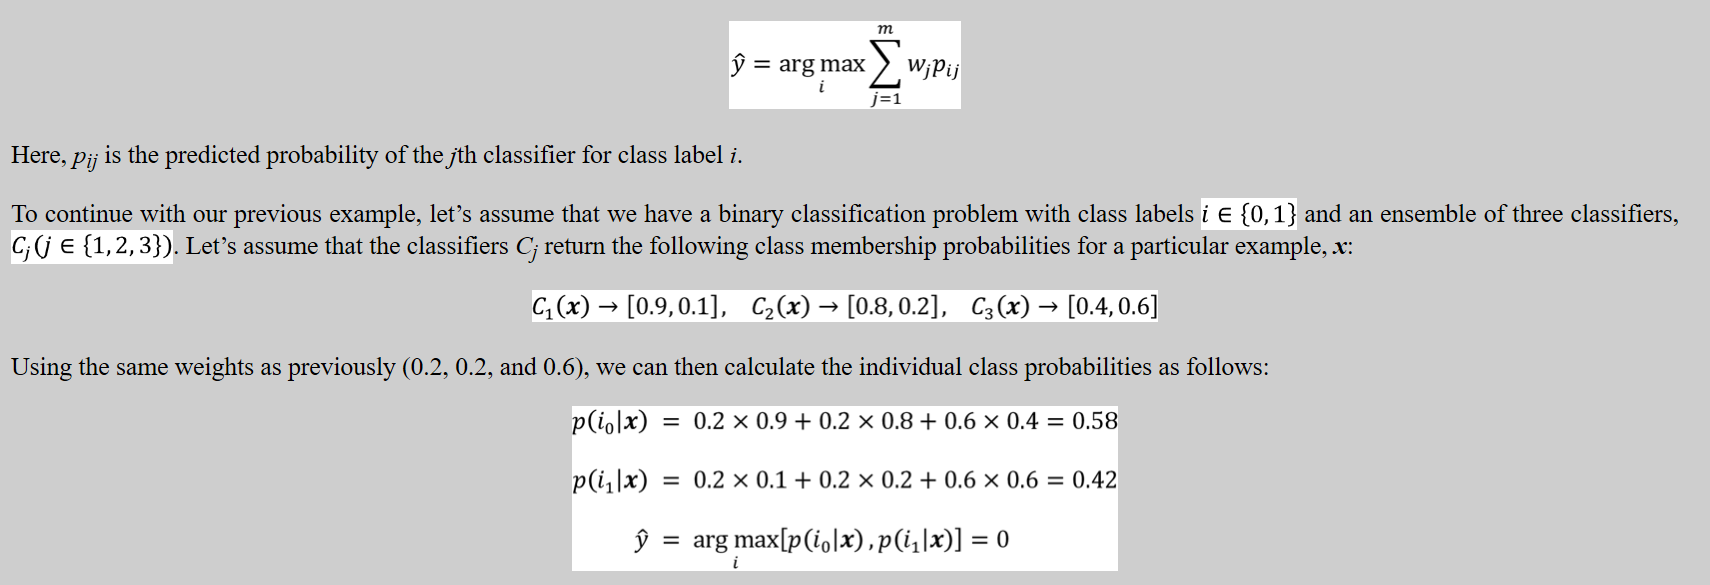
and note they are in probability

In [2]:
ex = np.array([[0.9,0.1],[0.8,0.2],[0.4,0.6]])

p = np.average(ex, axis =0, weights= (0.2,0.2,.6))
print(p)
np.argmax(p)


[0.58 0.42]


np.int64(0)

# Implementing Majorityvoteclassifire in python

In [9]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import _name_estimators
import numpy as np
import operator

class MajorityVoteClassifier(ClassifierMixin, BaseEstimator):  # ClassifierMixin must come first for sklearn 1.6+
    def __init__(self, classifiers, vote="classlabel", weights=None):
        self.classifiers = classifiers
        self.vote = vote
        self.weights = weights

    @property
    def named_classifiers(self):
        return {key: value for key, value in _name_estimators(self.classifiers)}

    def fit(self, X, y):
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError("vote must be 'probability' or 'classlabel'")
        if self.weights is not None and len(self.weights) != len(self.classifiers):
            raise ValueError("Number of classifiers and weights must be equal")
        self.labelEnc_ = LabelEncoder()
        self.labelEnc_.fit(y)
        self.classes_ = self.labelEnc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.labelEnc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        if self.vote == "probability":
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.asarray([clf.predict(X) for clf in self.classifiers_]).T
            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(np.bincount(x, weights=self.weights)),
                axis=1, arr=predictions
            )
        maj_vote = self.labelEnc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        probas = np.asarray([clf.predict_proba(X) for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        if not deep:
            return super().get_params(deep=False)
        
        out = super().get_params(deep=False)
        out.update(self.named_classifiers)

       
        for name, step in self.named_classifiers.items():
            for key, value in step.get_params(deep=True).items():
                    out[f'{name}__{key}'] = value
        return out


In [10]:
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X,y = iris.data[50:, [1,2]], iris.target[50:]

#print(X)
le = LabelEncoder()
y = le.fit_transform(y)
#print(y)

x_train,x_test, y_train, y_test = train_test_split(X,y, test_size= 0.5, stratify= y, random_state= 21)




Using the training dataset, we now will train three different classifiers:
    
      Logistic regression classifier
      Decision tree classifier
      k-nearest neighbors classifier

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

clf_0 = LogisticRegression(penalty= "l2", solver= "lbfgs", random_state= 21, C= 0.001)

clf_1 = DecisionTreeClassifier(criterion= "entropy", max_depth= 1, random_state= 2)

clf_2 = KNeighborsClassifier(n_neighbors= 1, p= 2, metric="minkowski")

# metric algo calculates distance between the points, while p is the power of the algo

pipe_1 = make_pipeline( StandardScaler(), clf_0)
#note decision tree is scale invariant therefore no need to scale
pipe_2 = make_pipeline(StandardScaler() , clf_2)

clf_labels = ["Logistic regression", "Decision tree", "Knn"]
print("The 10 fold validation is")

for clf, label in zip([pipe_1, clf_1, pipe_2], clf_labels):
    score = cross_val_score(estimator= clf, X= x_train, y= y_train, cv = 10, scoring="roc_auc")
    print(f"the roc auc is {score.mean()} [{label}]")
    #print(f"")

    


The 10 fold validation is
the roc auc is 0.8916666666666668 [Logistic regression]
the roc auc is 0.8333333333333334 [Decision tree]
the roc auc is 0.7833333333333334 [Knn]


# Now lets combine individual classifiers for majority rule voting

In [12]:
mv_clf = MajorityVoteClassifier(classifiers= [pipe_1, clf_1, pipe_2])

clf_labels +=  ["Majority Voting"]

all_clf = [pipe_1, clf_1, pipe_2, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator= clf, X=x_train, y=y_train, cv= 10, scoring="roc_auc")

    print(f"the mean of roc auc for each classifre and combined {scores.mean()}[{label}]")
    

the mean of roc auc for each classifre and combined 0.8916666666666668[Logistic regression]
the mean of roc auc for each classifre and combined 0.8333333333333334[Decision tree]
the mean of roc auc for each classifre and combined 0.7833333333333334[Knn]
the mean of roc auc for each classifre and combined 0.8916666666666668[Majority Voting]


# Evaluating and tuning the ensemble classifier

In [17]:
from sklearn.model_selection import GridSearchCV
mv_clf.get_params()
# lets try out the best feature for logistic regression and decision tree in 
# gridsearch cv using the  best params based on above output

params =  { 'decisiontreeclassifier__max_depth': [1,2], 'pipeline-1__logisticregression__C': [0.001,.1,100]}

grid = GridSearchCV(estimator= mv_clf, param_grid= params, cv = 10, scoring = 'roc_auc')

grid.fit(x_train, y_train)


for r,_ in enumerate (grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_score = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f"{mean_score:.3f} +/- {std_score} {params}")





0.892 +/- 0.12936812246883353 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__logisticregression__C': 0.001}
0.925 +/- 0.10833333333333335 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__logisticregression__C': 0.1}
0.908 +/- 0.12047360245667468 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__logisticregression__C': 100}
0.892 +/- 0.12936812246883353 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__logisticregression__C': 0.001}
0.925 +/- 0.10833333333333335 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__logisticregression__C': 0.1}
0.908 +/- 0.12047360245667468 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__logisticregression__C': 100}
